In [3]:
import pandas as pd

df = pd.read_csv("../data/processed/amazon_clean.csv", encoding="utf-8-sig")
title_df = df[["title"]]
print(title_df.head())


                                     title
0            10-Day Green Smoothie Cleanse
1                        11/22/63: A Novel
2  12 Rules for Life: An Antidote to Chaos
3                                     1984
4                   1984 (Signet Classics)


In [4]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words='english',
    lowercase=True
)

X = vectorizer.fit_transform(title_df['title'])

freq = X.sum(axis=0)

word_freq = sorted(
    zip(vectorizer.get_feature_names_out(), freq.tolist()[0]),
    key=lambda x: x[1],
    reverse=True
)

print(word_freq[:30])

[('book', 91), ('love', 47), ('novel', 46), ('life', 29), ('guide', 28), ('kids', 28), ('edition', 26), ('man', 24), ('coloring', 22), ('american', 20), ('dog', 20), ('good', 20), ('series', 20), ('big', 17), ('cookbook', 17), ('people', 16), ('personal', 16), ('secret', 16), ('shades', 16), ('world', 16), ('art', 15), ('little', 15), ('recipes', 15), ('books', 14), ('girl', 14), ('habits', 14), ('kid', 14), ('languages', 14), ('manual', 14), ('body', 13)]


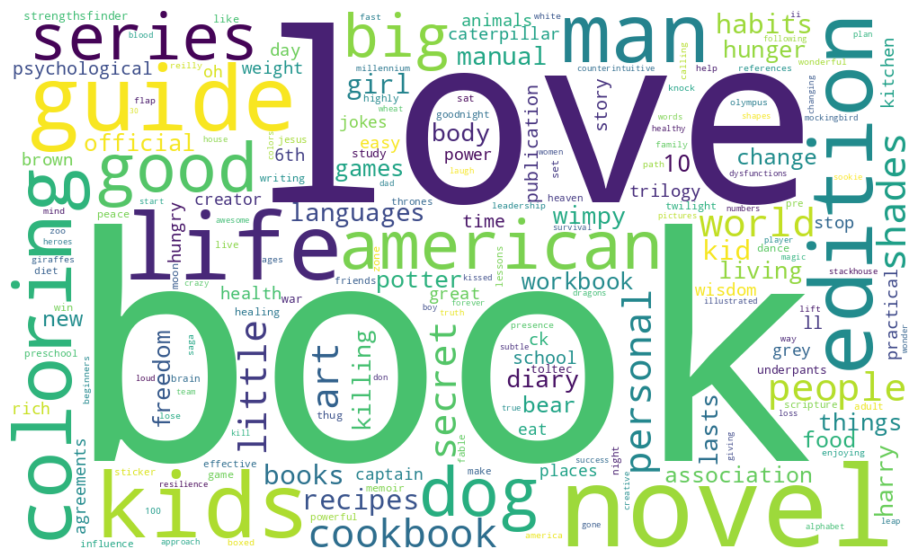

In [5]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

word_freq_dict = dict(word_freq)

wc = WordCloud(
    width=1000,
    height=600,
    background_color='white'
).generate_from_frequencies(word_freq_dict)

plt.figure(figsize=(12, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()